# 3a. Experiments — QuadX-Hover-v4

This notebook trains and compares three policies on `PyFlyt/QuadX-Hover-v4`:

| Agent | Type | Library |
|---|---|---|
| **Random** | Baseline | — |
| **SAC** | Off-policy, entropy-regularised | Custom PyTorch |
| **PPO** | On-policy, clipped surrogate | Stable-Baselines3 |

All three are evaluated on the same seeds with the same evaluation function so results are directly comparable.

**Flight mode used:** `7` (position + yaw setpoint, full PID stack — easiest) as a sanity check that both algorithms converge.  
Change `FLIGHT_MODE` below to any of `[-1, 0, 4, 6, 7]` to reproduce harder conditions.

## 0. Imports & config

In [1]:
import numpy as np
import gymnasium as gym
import PyFlyt.gym_envs          # registers PyFlyt envs
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from algorithms import SACAgent, PPOAgent, evaluate_policy

# ── reproducibility ──────────────────────────────────────────
SEED        = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── experiment knobs ─────────────────────────────────────────
ENV_ID      = "PyFlyt/QuadX-Hover-v4"
FLIGHT_MODE = 7          # change to 0, 4, 6 etc. for harder modes
MAX_STEPS   = 500        # steps per episode during evaluation
EVAL_EPS    = 10         # evaluation episodes (for mean / std)
EVAL_SEEDS  = list(range(SEED, SEED + EVAL_EPS))   # fixed eval seeds

print(f"Environment : {ENV_ID}  |  flight_mode = {FLIGHT_MODE}")
print(f"Device      : {'cuda' if torch.cuda.is_available() else 'cpu'}")

Environment : PyFlyt/QuadX-Hover-v4  |  flight_mode = 7
Device      : cuda


## 1. Shared evaluation helper

A single function is used for **every** agent so comparisons are fair.
It accepts any callable `policy_fn(obs) → action`.

In [2]:
def eval_agent(policy_fn, label, n_episodes=EVAL_EPS, seeds=EVAL_SEEDS, max_steps=MAX_STEPS):
    """
    Evaluate policy_fn on n_episodes with fixed seeds.
    Returns (mean, std, list_of_returns).
    """
    env = gym.make(ENV_ID, flight_mode=FLIGHT_MODE)
    returns = []

    for seed in tqdm(seeds, desc=f"Eval [{label}]"):
        obs, _ = env.reset(seed=seed)
        total  = 0.0

        for _ in range(max_steps):
            action = policy_fn(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            total += reward
            if terminated or truncated:
                break

        returns.append(total)

    env.close()
    mean, std = float(np.mean(returns)), float(np.std(returns))
    print(f"  {label:<10}  mean={mean:8.2f}  std={std:7.2f}")
    return mean, std, returns

## 2. Random baseline

In [3]:
_env_tmp = gym.make(ENV_ID, flight_mode=FLIGHT_MODE)
_action_space = _env_tmp.action_space
_env_tmp.close()

def random_policy(obs):
    return _action_space.sample()

rand_mean, rand_std, rand_returns = eval_agent(random_policy, "Random")

Eval [Random]:   0%|          | 0/10 [00:00<?, ?it/s]

Eval [Random]:  10%|█         | 1/10 [00:06<00:58,  6.51s/it]

Eval [Random]:  20%|██        | 2/10 [00:07<00:25,  3.21s/it]

Eval [Random]:  30%|███       | 3/10 [00:08<00:14,  2.14s/it]

Eval [Random]:  40%|████      | 4/10 [00:09<00:09,  1.63s/it]

...

Eval [Random]:  70%|███████   | 7/10 [00:11<00:03,  1.05s/it]

Eval [Random]:  80%|████████  | 8/10 [00:12<00:01,  1.02it/s]

Eval [Random]:  90%|█████████ | 9/10 [00:13<00:00,  1.05it/s]

Eval [Random]: 100%|██████████| 10/10 [00:14<00:00,  1.42s/it]

  Random      mean=  -46.62  std= 199.16


## 3. SAC — Soft Actor-Critic

### 3.1  What SAC does

SAC maximises a **maximum-entropy** objective:

$$J(\pi) = \sum_t \mathbb{E}_{(s_t,a_t)\sim\pi}\bigl[r(s_t,a_t) + \alpha\,\mathcal{H}(\pi(\cdot|s_t))\bigr]$$

The entropy bonus $\alpha\,\mathcal{H}$ keeps the policy stochastic, discouraging premature convergence.  
Key properties:
- **Off-policy** — every transition is stored in a replay buffer and can be re-used for many gradient updates.
- **Actor**: squashed-Gaussian, outputs `tanh(Normal(μ,σ))` → actions always in (-1,1), then linearly rescaled.
- **Two critics** (Q1, Q2) with soft-updated target networks → reduces overestimation bias.

### 3.2  Hyperparameters

In [4]:
SAC_EPISODES   = 300    # training episodes  (~300 × 500 = 150 k steps)
SAC_MAX_STEPS  = 500    # max steps per training episode
SAC_BATCH_SIZE = 256
SAC_GAMMA      = 0.99
SAC_TAU        = 0.005
SAC_ALPHA      = 0.2
SAC_LR         = 3e-4
SAC_BUFFER     = 500_000

### 3.3  Training loop

In [6]:
env_sac = gym.make(ENV_ID, flight_mode=FLIGHT_MODE)

state_dim  = env_sac.observation_space.shape[0]   # 21
action_dim = env_sac.action_space.shape[0]         # 4

sac = SACAgent(
    state_dim  = state_dim,
    action_dim = action_dim,
    action_low  = env_sac.action_space.low,
    action_high = env_sac.action_space.high,
    gamma       = SAC_GAMMA,
    tau         = SAC_TAU,
    alpha       = SAC_ALPHA,
    lr          = SAC_LR,
    buffer_size = SAC_BUFFER,
)

sac_train_returns = []

for ep in tqdm(range(SAC_EPISODES), desc="Training SAC"):
    obs, _ = env_sac.reset(seed=SEED + ep)
    ep_reward = 0.0

    for _ in range(SAC_MAX_STEPS):
        # act() returns normalised action in (-1, 1)
        a_norm   = sac.act(obs, deterministic=False)
        # env_action() rescales to environment bounds
        a_env    = sac.env_action(obs, deterministic=False)

        next_obs, reward, terminated, truncated, _ = env_sac.step(a_env)
        done = terminated or truncated

        # store normalised action — gradients stay well-conditioned
        sac.store(obs, a_norm, reward, next_obs, float(done))
        sac.update(batch_size=SAC_BATCH_SIZE)

        obs = next_obs
        ep_reward += reward

        if done:
            break

    sac_train_returns.append(ep_reward)

env_sac.close()
print(f"\nSAC training done. Last-10 mean: {np.mean(sac_train_returns[-10:]):.2f}")

Training SAC:   0%|          | 0/300 [00:00<?, ?it/s]

Training SAC:   0%|          | 1/300 [00:05<29:37,  5.95s/it]

Training SAC:   1%|          | 2/300 [00:12<32:32,  6.55s/it]

Training SAC:   1%|          | 3/300 [00:19<33:36,  6.79s/it]

Training SAC:   1%|▏         | 4/300 [00:28<36:31,  7.40s/it]

...

Training SAC:  99%|█████████▉| 297/300 [32:44<00:19,  6.44s/it]

Training SAC:  99%|█████████▉| 298/300 [32:50<00:12,  6.43s/it]

Training SAC: 100%|█████████▉| 299/300 [32:57<00:06,  6.44s/it]

Training SAC: 100%|██████████| 300/300 [33:03<00:00,  6.61s/it]


SAC training done. Last-10 mean: 529.17


### 3.4  Evaluate SAC

In [7]:
sac_mean, sac_std, sac_returns = eval_agent(
    lambda obs: sac.predict(obs, deterministic=True)[0],
    label="SAC"
)

Eval [SAC]:   0%|          | 0/10 [00:00<?, ?it/s]

Eval [SAC]:  10%|█         | 1/10 [00:01<00:10,  1.14s/it]

Eval [SAC]:  20%|██        | 2/10 [00:02<00:08,  1.10s/it]

Eval [SAC]:  30%|███       | 3/10 [00:03<00:07,  1.10s/it]

Eval [SAC]:  40%|████      | 4/10 [00:04<00:06,  1.11s/it]

...

Eval [SAC]:  70%|███████   | 7/10 [00:07<00:03,  1.12s/it]

Eval [SAC]:  80%|████████  | 8/10 [00:08<00:02,  1.11s/it]

Eval [SAC]:  90%|█████████ | 9/10 [00:09<00:01,  1.09s/it]

Eval [SAC]: 100%|██████████| 10/10 [00:10<00:00,  1.10s/it]

  SAC         mean=  573.50  std=  12.48


### 3.5  Training curve — SAC

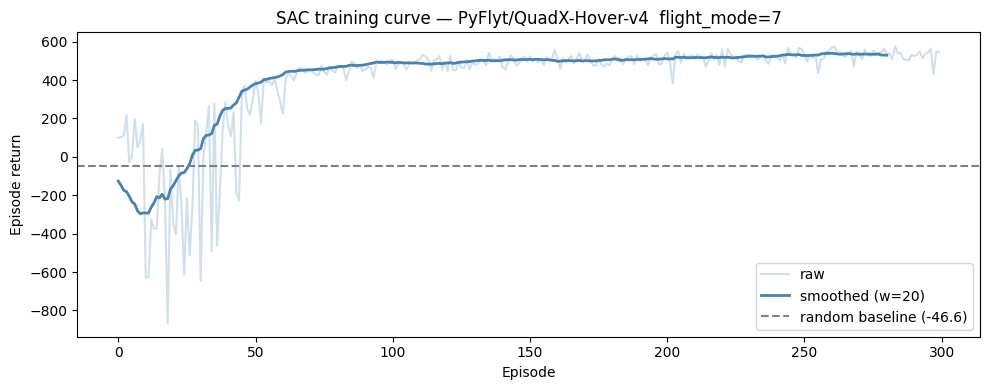

In [8]:
def smooth(x, w=20):
    """Simple moving average for plotting."""
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sac_train_returns, alpha=0.25, color='steelblue', label='raw')
ax.plot(
    range(len(smooth(sac_train_returns))),
    smooth(sac_train_returns),
    color='steelblue', lw=2, label='smoothed (w=20)'
)
ax.axhline(rand_mean, color='grey', linestyle='--', label=f'random baseline ({rand_mean:.1f})')
ax.set_xlabel('Episode')
ax.set_ylabel('Episode return')
ax.set_title(f'SAC training curve — {ENV_ID}  flight_mode={FLIGHT_MODE}')
ax.legend()
plt.tight_layout()
plt.show()

## 4. PPO — Proximal Policy Optimisation

### 4.1  What PPO does

PPO is an **on-policy** policy-gradient algorithm. It collects a batch of trajectories under the current policy, then maximises the clipped surrogate objective:

$$L^{\text{CLIP}}(\theta) = \mathbb{E}_t\Bigl[\min\bigl(r_t(\theta)\hat{A}_t,\; \text{clip}(r_t(\theta), 1-\varepsilon, 1+\varepsilon)\hat{A}_t\bigr)\Bigr]$$

where $r_t(\theta) = \pi_\theta(a_t|s_t)/\pi_{\theta_{\text{old}}}(a_t|s_t)$ is the probability ratio and $\hat{A}_t$ is the GAE advantage estimate.  
The clip keeps the update close to the old policy, providing the stability SAC gets via soft target updates.

Key properties vs SAC:
- **On-policy** — data is discarded after each update → less sample-efficient but no off-policy bias.
- **No replay buffer** — simpler memory footprint.
- **Stable by design** — clip prevents destructive large updates.

### 4.2  Hyperparameters

In [9]:
PPO_TIMESTEPS = 300_000   # total env steps  (~same budget as SAC)
PPO_N_STEPS   = 2048      # rollout length before each update
PPO_BATCH     = 64
PPO_EPOCHS    = 10
PPO_GAMMA     = 0.99
PPO_GAE       = 0.95
PPO_CLIP      = 0.2
PPO_LR        = 3e-4

### 4.3  Training

In [10]:
env_ppo = gym.make(ENV_ID, flight_mode=FLIGHT_MODE)

ppo = PPOAgent(
    env         = env_ppo,
    learning_rate = PPO_LR,
    n_steps     = PPO_N_STEPS,
    batch_size  = PPO_BATCH,
    n_epochs    = PPO_EPOCHS,
    gamma       = PPO_GAMMA,
    gae_lambda  = PPO_GAE,
    clip_range  = PPO_CLIP,
    verbose     = 1,
    seed        = SEED,
)

ppo.train(total_timesteps=PPO_TIMESTEPS)
env_ppo.close()

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
                             


f:\Dev\anaconda\envs\rl\lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


                                                                                                                                                 
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 402      |
|    ep_rew_mean     | 241      |
| time/              |          |
|    fps             | 238      |
|    iterations      | 1        |
|    time_elapsed    | 8        |
|    total_timesteps | 2048     |
---------------------------------                                                                                                                                                 
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 402         |
|    ep_rew_mean          | 235         |
| time/                   |             |
|    fps                  | 203         |
|    iterations           | 2           |
|    time_elapsed         | 20          |
|    total_timesteps      | 4096 

### 4.4  Evaluate PPO

In [11]:
ppo_mean, ppo_std, ppo_returns = eval_agent(
    lambda obs: ppo.predict(obs, deterministic=True)[0],
    label="PPO"
)

Eval [PPO]:   0%|          | 0/10 [00:00<?, ?it/s]

Eval [PPO]:  10%|█         | 1/10 [00:01<00:10,  1.17s/it]

Eval [PPO]:  20%|██        | 2/10 [00:02<00:09,  1.19s/it]

Eval [PPO]:  30%|███       | 3/10 [00:03<00:08,  1.18s/it]

Eval [PPO]:  40%|████      | 4/10 [00:04<00:07,  1.18s/it]

...

Eval [PPO]:  70%|███████   | 7/10 [00:08<00:03,  1.19s/it]

Eval [PPO]:  80%|████████  | 8/10 [00:09<00:02,  1.19s/it]

Eval [PPO]:  90%|█████████ | 9/10 [00:10<00:01,  1.18s/it]

Eval [PPO]: 100%|██████████| 10/10 [00:11<00:00,  1.19s/it]

  PPO         mean=  837.51  std=  29.42


## 5. Results summary

### 5.1  Numerical table

In [12]:
print(f"{'Agent':<12} {'Mean return':>14} {'Std':>10} {'95% CI':>20}")
print("-" * 60)

for label, mean, std, rets in [
    ("Random",  rand_mean, rand_std, rand_returns),
    ("SAC",     sac_mean,  sac_std,  sac_returns),
    ("PPO",     ppo_mean,  ppo_std,  ppo_returns),
]:
    n    = len(rets)
    se   = std / np.sqrt(n)
    ci_lo = mean - 1.96 * se
    ci_hi = mean + 1.96 * se
    print(f"{label:<12} {mean:>14.2f} {std:>10.2f}  [{ci_lo:8.2f}, {ci_hi:8.2f}]")

Agent           Mean return        Std               95% CI
------------------------------------------------------------
Random               -46.62     199.16  [ -170.06,    76.82]
SAC                  573.50      12.48  [  565.76,   581.23]
PPO                  837.51      29.42  [  819.28,   855.75]


### 5.2  Bar chart with error bars

Error bars show ±1 standard deviation across evaluation episodes.

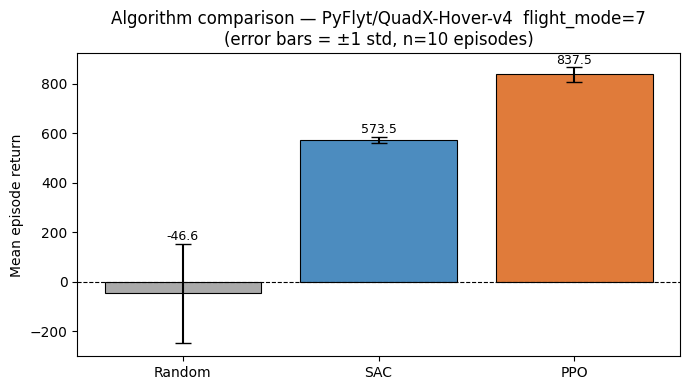

In [13]:
labels   = ["Random", "SAC", "PPO"]
means    = [rand_mean, sac_mean, ppo_mean]
stds     = [rand_std,  sac_std,  ppo_std]
colors   = ["#aaaaaa", "#4c8cbf", "#e07b3a"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, means, yerr=stds, capsize=6,
              color=colors, edgecolor='black', linewidth=0.8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Mean episode return')
ax.set_title(f'Algorithm comparison — {ENV_ID}  flight_mode={FLIGHT_MODE}\n'
             f'(error bars = ±1 std, n={EVAL_EPS} episodes)')

for bar, mean, std in zip(bars, means, stds):
    ax.text(bar.get_x() + bar.get_width()/2, mean + std + 2,
            f'{mean:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### 5.3  Return distribution (box plot)

Box plots show the full distribution over episodes, not just the mean —
recommended by Agarwal et al. (NeurIPS 2021) for deep RL comparisons.

C:\Users\Megaport\AppData\Local\Temp\ipykernel_8200\2775706669.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


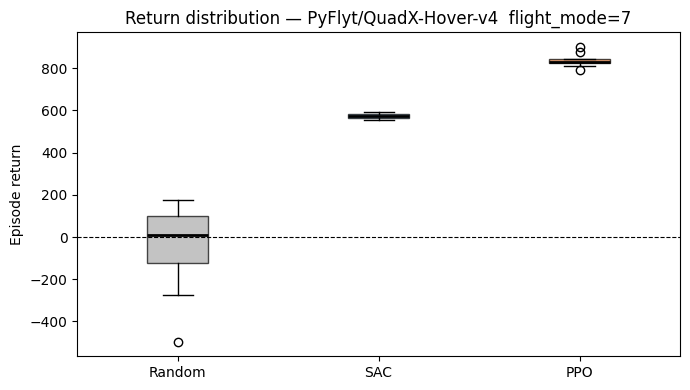

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
bp = ax.boxplot(
    [rand_returns, sac_returns, ppo_returns],
    labels=labels,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
)

for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Episode return')
ax.set_title(f'Return distribution — {ENV_ID}  flight_mode={FLIGHT_MODE}')
plt.tight_layout()
plt.show()

### 5.4  SAC vs PPO training curves side-by-side

Note: PPO's training curve comes from SB3's internal logger (printed above).  
Here we plot the SAC curve alongside the flat random baseline for scale.

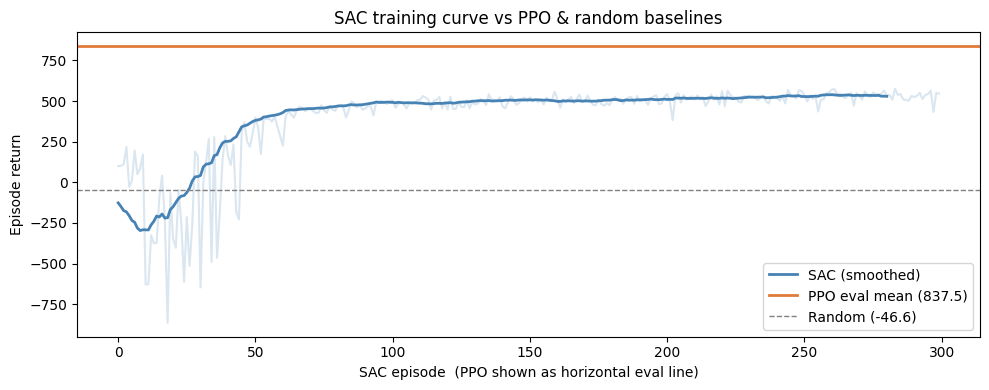

In [15]:
fig, ax = plt.subplots(figsize=(10, 4))

# SAC episode-level curve
ax.plot(sac_train_returns, alpha=0.2, color='steelblue')
ax.plot(smooth(sac_train_returns), color='steelblue', lw=2, label='SAC (smoothed)')

# PPO evaluated return (single horizontal line — SB3 doesn't expose per-episode easily)
ax.axhline(ppo_mean,  color='#e07b3a', linestyle='-',  lw=2, label=f'PPO eval mean ({ppo_mean:.1f})')
ax.axhline(rand_mean, color='grey',    linestyle='--', lw=1, label=f'Random ({rand_mean:.1f})')

ax.set_xlabel('SAC episode  (PPO shown as horizontal eval line)')
ax.set_ylabel('Episode return')
ax.set_title('SAC training curve vs PPO & random baselines')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Save models

In [16]:
import torch, os

os.makedirs("checkpoints", exist_ok=True)

# SAC — save actor weights (enough to reproduce predict())
torch.save(sac.actor.state_dict(), f"checkpoints/sac_actor_mode{FLIGHT_MODE}.pt")
# or save the whole agent state if you want to resume training:
torch.save({
    'actor':  sac.actor.state_dict(),
    'q1':     sac.q1.state_dict(),
    'q2':     sac.q2.state_dict(),
    'q1_t':   sac.q1_t.state_dict(),
    'q2_t':   sac.q2_t.state_dict(),
}, f"checkpoints/sac_full_mode{FLIGHT_MODE}.pt")

# PPO — SB3 zip format (required for tournament submission)
ppo.save(f"checkpoints/ppo_mode{FLIGHT_MODE}")

print("Checkpoints saved to ./checkpoints/")

Checkpoints saved to ./checkpoints/


## 7. Reload & verify (sanity check)

Confirm both saved models reproduce the same evaluation scores after reloading.

In [17]:
# ── reload SAC ───────────────────────────────────────────────
from algorithms import SACAgent, _Actor

_env_tmp = gym.make(ENV_ID, flight_mode=FLIGHT_MODE)

sac_loaded = SACAgent(
    state_dim   = _env_tmp.observation_space.shape[0],
    action_dim  = _env_tmp.action_space.shape[0],
    action_low  = _env_tmp.action_space.low,
    action_high = _env_tmp.action_space.high,
)
ckpt = torch.load(f"checkpoints/sac_full_mode{FLIGHT_MODE}.pt", map_location='cpu')
sac_loaded.actor.load_state_dict(ckpt['actor'])
sac_loaded.q1.load_state_dict(ckpt['q1'])
sac_loaded.q2.load_state_dict(ckpt['q2'])
_env_tmp.close()

sac_rl_mean, sac_rl_std, _ = eval_agent(
    lambda obs: sac_loaded.predict(obs, deterministic=True)[0],
    label="SAC (reloaded)"
)

# ── reload PPO ───────────────────────────────────────────────
env_reload = gym.make(ENV_ID, flight_mode=FLIGHT_MODE)
ppo_loaded = PPOAgent.load(f"checkpoints/ppo_mode{FLIGHT_MODE}", env=env_reload)

ppo_rl_mean, ppo_rl_std, _ = eval_agent(
    lambda obs: ppo_loaded.predict(obs, deterministic=True)[0],
    label="PPO (reloaded)"
)
env_reload.close()

print("\nSanity check — scores should match original evaluation:")
print(f"  SAC  original={sac_mean:.2f}  reloaded={sac_rl_mean:.2f}")
print(f"  PPO  original={ppo_mean:.2f}  reloaded={ppo_rl_mean:.2f}")

Eval [SAC (reloaded)]:   0%|          | 0/10 [00:00<?, ?it/s]

Eval [SAC (reloaded)]:  10%|█         | 1/10 [00:01<00:09,  1.09s/it]

Eval [SAC (reloaded)]:  20%|██        | 2/10 [00:02<00:09,  1.14s/it]

Eval [SAC (reloaded)]:  30%|███       | 3/10 [00:03<00:07,  1.12s/it]

Eval [SAC (reloaded)]:  40%|████      | 4/10 [00:04<00:06,  1.10s/it]

...

Eval [PPO (reloaded)]:  70%|███████   | 7/10 [00:07<00:03,  1.08s/it]

Eval [PPO (reloaded)]:  80%|████████  | 8/10 [00:08<00:02,  1.08s/it]

Eval [PPO (reloaded)]:  90%|█████████ | 9/10 [00:09<00:01,  1.08s/it]

Eval [PPO (reloaded)]: 100%|██████████| 10/10 [00:10<00:00,  1.09s/it]

  PPO (reloaded)  mean=  837.51  std=  29.42

Sanity check — scores should match original evaluation:
  SAC  original=573.50  reloaded=573.50
  PPO  original=837.51  reloaded=837.51


## 8. Multi-mode comparison (optional — slow)

Trains both algorithms on every flight mode and compares them.
**Skip this cell** unless you have time — each mode takes ~10 min on CPU.

In [18]:
MODES_TO_TEST = [7, 6, 4, 0, -1]   # easiest → hardest
multi_results = {}              # results[mode] = {agent: (mean, std)}

for mode in MODES_TO_TEST:
    print(f"\n{'='*50}")
    print(f"  flight_mode = {mode}")
    print(f"{'='*50}")

    env_m = gym.make(ENV_ID, flight_mode=mode)
    multi_results[mode] = {}

    # -- random baseline --
    _as = env_m.action_space
    rm, rs, _ = eval_agent(lambda obs: _as.sample(), "Random",
                           seeds=list(range(SEED, SEED+EVAL_EPS)))
    multi_results[mode]["Random"] = (rm, rs)

    # -- SAC --
    sac_m = SACAgent(
        state_dim   = env_m.observation_space.shape[0],
        action_dim  = env_m.action_space.shape[0],
        action_low  = env_m.action_space.low,
        action_high = env_m.action_space.high,
    )
    for ep in range(200):
        obs, _ = env_m.reset(seed=SEED + ep)
        for _ in range(500):
            a_norm = sac_m.act(obs)
            a_env  = sac_m.env_action(obs)
            nobs, r, term, trunc, _ = env_m.step(a_env)
            sac_m.store(obs, a_norm, r, nobs, float(term or trunc))
            sac_m.update()
            obs = nobs
            if term or trunc: break

    sm, ss, _ = eval_agent(
        lambda obs: sac_m.predict(obs, deterministic=True)[0], "SAC",
        seeds=list(range(SEED, SEED+EVAL_EPS))
    )
    multi_results[mode]["SAC"] = (sm, ss)

    # -- PPO --
    ppo_m = PPOAgent(env_m, verbose=0, seed=SEED)
    ppo_m.train(total_timesteps=200_000)

    pm, ps, _ = eval_agent(
        lambda obs: ppo_m.predict(obs, deterministic=True)[0], "PPO",
        seeds=list(range(SEED, SEED+EVAL_EPS))
    )
    multi_results[mode]["PPO"] = (pm, ps)

    env_m.close()

# ── print summary table ───────────────────────────────────────
print(f"\n{'Mode':<6} {'Agent':<10} {'Mean':>10} {'Std':>8}")
print("-" * 38)
for mode in MODES_TO_TEST:
    for agent, (m, s) in multi_results[mode].items():
        print(f"{mode:<6} {agent:<10} {m:>10.2f} {s:>8.2f}")


  flight_mode = 7


Eval [Random]:   0%|          | 0/10 [00:00<?, ?it/s]

Eval [Random]:  10%|█         | 1/10 [00:00<00:06,  1.39it/s]

Eval [Random]:  20%|██        | 2/10 [00:01<00:05,  1.38it/s]

Eval [Random]:  30%|███       | 3/10 [00:02<00:05,  1.38it/s]

...

Eval [PPO]:  70%|███████   | 7/10 [00:02<00:01,  2.97it/s]

Eval [PPO]:  80%|████████  | 8/10 [00:02<00:00,  2.82it/s]

Eval [PPO]:  90%|█████████ | 9/10 [00:03<00:00,  2.80it/s]

Eval [PPO]: 100%|██████████| 10/10 [00:03<00:00,  2.87it/s]

  PPO         mean=  -26.61  std=   1.16

Mode   Agent            Mean      Std
--------------------------------------
7      Random          62.30   114.17
7      SAC            607.51     7.26
7      PPO            737.69     1.39
6      Random           4.45    91.14
6      SAC           -291.86   383.84
6      PPO            577.03    11.81
4      Random           0.56   160.62
4      SAC            547.16     7.13
4      PPO            847.45     1.06
0      Random          37.69   268.59
0      SAC           -259.69    38.34
0      PPO            321.84   191.93
-1     Random         204.87    22.48
-1     SAC             -7.22   186.04
-1     PPO            -26.61     1.16


### Multi-mode bar chart

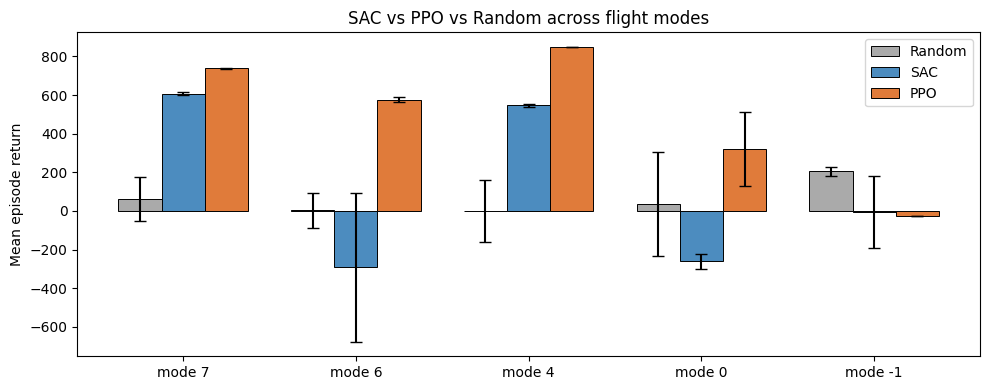

In [19]:
if multi_results:
    agents = ["Random", "SAC", "PPO"]
    x      = np.arange(len(MODES_TO_TEST))
    width  = 0.25
    cols   = ["#aaaaaa", "#4c8cbf", "#e07b3a"]

    fig, ax = plt.subplots(figsize=(10, 4))
    for i, (agent, col) in enumerate(zip(agents, cols)):
        means = [multi_results[m][agent][0] for m in MODES_TO_TEST]
        stds  = [multi_results[m][agent][1] for m in MODES_TO_TEST]
        ax.bar(x + i*width, means, width, yerr=stds, capsize=4,
               label=agent, color=col, edgecolor='black', linewidth=0.7)

    ax.set_xticks(x + width)
    ax.set_xticklabels([f"mode {m}" for m in MODES_TO_TEST])
    ax.set_ylabel('Mean episode return')
    ax.set_title('SAC vs PPO vs Random across flight modes')
    ax.legend()
    plt.tight_layout()
    plt.show()

In [20]:
print(f"{'Mode':<6} {'Agent':<10} {'Mean':>10} {'Std':>8}")
print("-" * 38)
for mode, agents in multi_results.items():
    for agent, (mean, std) in agents.items():
        print(f"{mode:<6} {agent:<10} {mean:>10.2f} {std:>8.2f}")

Mode   Agent            Mean      Std
--------------------------------------
7      Random          62.30   114.17
7      SAC            607.51     7.26
7      PPO            737.69     1.39
6      Random           4.45    91.14
6      SAC           -291.86   383.84
6      PPO            577.03    11.81
4      Random           0.56   160.62
4      SAC            547.16     7.13
4      PPO            847.45     1.06
0      Random          37.69   268.59
0      SAC           -259.69    38.34
0      PPO            321.84   191.93
-1     Random         204.87    22.48
-1     SAC             -7.22   186.04
-1     PPO            -26.61     1.16
